In [ ]:
import kagglehub
import numpy as np
import pandas as pd
import os

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tawfikelmetwally/employee-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'employee-dataset' dataset.
Path to dataset files: /kaggle/input/employee-dataset


In [ ]:
df = pd.read_csv(os.path.join(path,"Employee.csv"))

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Education                  4653 non-null   object
 1   JoiningYear                4653 non-null   int64 
 2   City                       4653 non-null   object
 3   PaymentTier                4653 non-null   int64 
 4   Age                        4653 non-null   int64 
 5   Gender                     4653 non-null   object
 6   EverBenched                4653 non-null   object
 7   ExperienceInCurrentDomain  4653 non-null   int64 
 8   LeaveOrNot                 4653 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 327.3+ KB


In [ ]:
df.head()

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1


In [ ]:
df.isnull().sum()

,0
Education,0
JoiningYear,0
City,0
PaymentTier,0
Age,0
Gender,0
EverBenched,0
ExperienceInCurrentDomain,0
LeaveOrNot,0


In [ ]:
df['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [ ]:
from sklearn.preprocessing import LabelEncoder

education_le = LabelEncoder()
City_le = LabelEncoder()
Gender_le = LabelEncoder()
EverBenched_le = LabelEncoder()
df['Education'] = education_le.fit_transform(df['Education'])
df['City'] = City_le.fit_transform(df['City'])
df['Gender'] = Gender_le.fit_transform(df['Gender'])
df['EverBenched'] = EverBenched_le.fit_transform(df['EverBenched'])

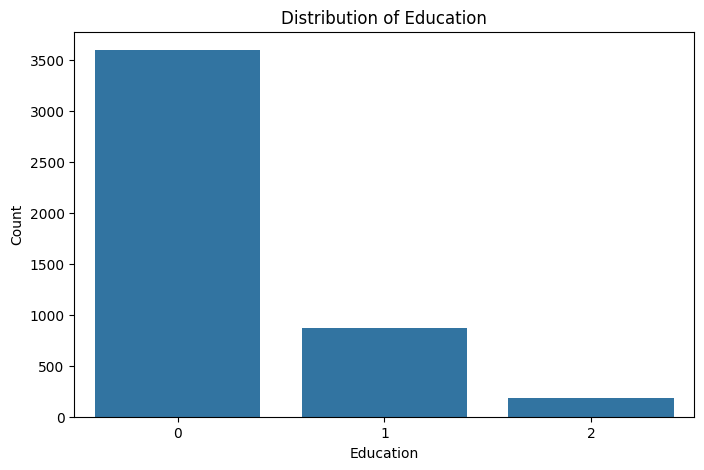

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.countplot(x='Education', data=df)
plt.title('Distribution of Education')
plt.xlabel('Education')
plt.ylabel('Count')
plt.show()


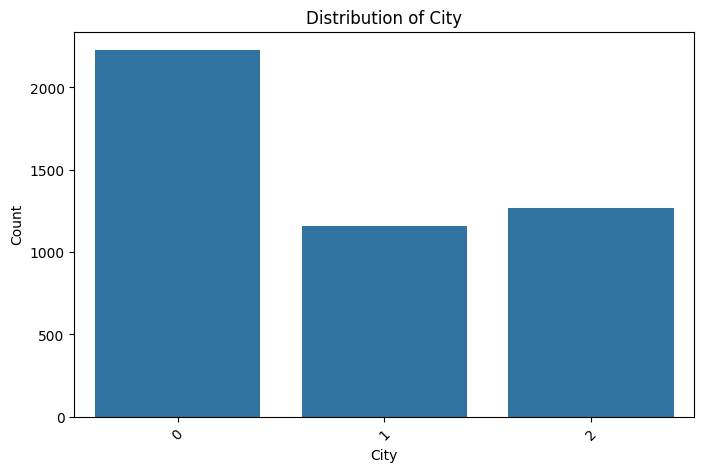

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='City', data=df)
plt.title('Distribution of City')
plt.xlabel('City')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

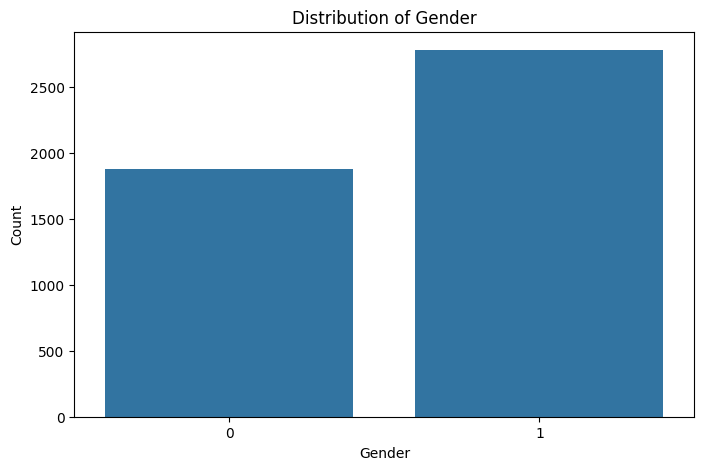

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Gender', data=df)
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

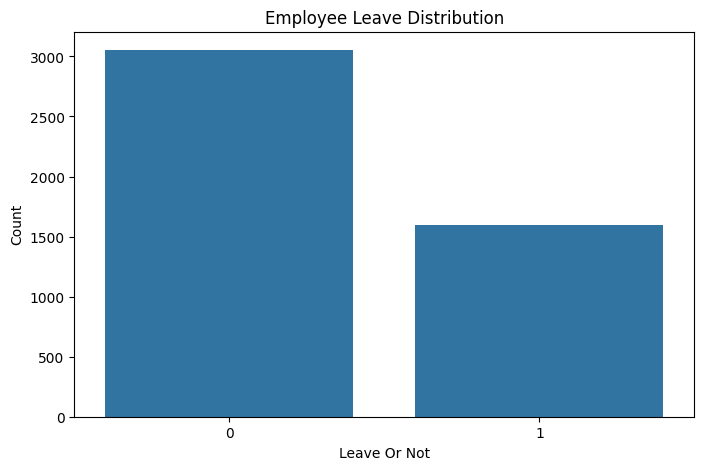

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='LeaveOrNot', data=df)
plt.title('Employee Leave Distribution')
plt.xlabel('Leave Or Not')
plt.ylabel('Count')
plt.show()

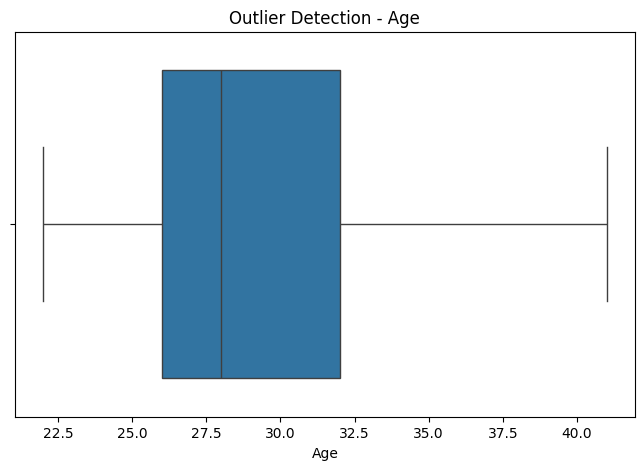

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Age'])
plt.title('Outlier Detection - Age')
plt.xlabel('Age')
plt.show()

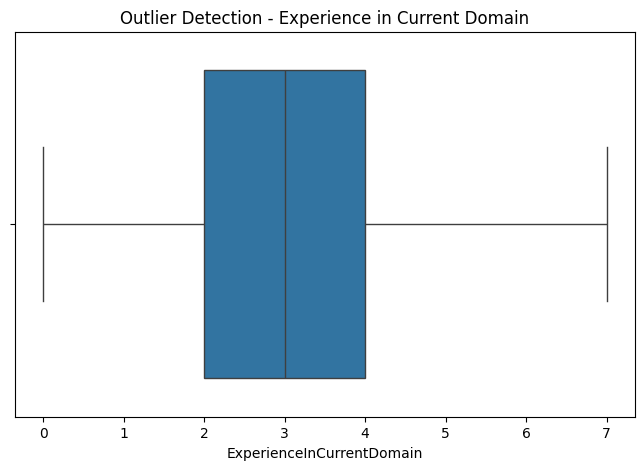

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['ExperienceInCurrentDomain'])
plt.title('Outlier Detection - Experience in Current Domain')
plt.xlabel('ExperienceInCurrentDomain')
plt.show()

In [ ]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Age'] < lower) | (df['Age'] > upper)]

print("Age Outliers:", len(outliers))

Age Outliers: 0


In [ ]:
Q1 = df['ExperienceInCurrentDomain'].quantile(0.25)
Q3 = df['ExperienceInCurrentDomain'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['ExperienceInCurrentDomain'] < lower) |
    (df['ExperienceInCurrentDomain'] > upper)
]

print("ExperienceInCurrentDomain Outliers:", len(outliers))

ExperienceInCurrentDomain Outliers: 0


In [ ]:
X = df.drop("LeaveOrNot", axis=1)

y = df["LeaveOrNot"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


In [ ]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = rf_model.predict(X_test)

In [ ]:
print("Accuracy")
print(accuracy_score(y_test,y_pred))

Accuracy
0.8313641245972073


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.84      0.92      0.88       611
           1       0.82      0.66      0.73       320

    accuracy                           0.83       931
   macro avg       0.83      0.79      0.80       931
weighted avg       0.83      0.83      0.83       931



In [ ]:
import joblib

# Dono ko alag-alag files mein dump kiya
joblib.dump(LabelEncoder, "LabelEncoder.joblib")
joblib.dump(rf_model, "rf_model.joblib")


['rf_model.joblib']

In [ ]:
# Load the scaler and model from the .joblib files
loaded_LebelEncoder = joblib.load("LabelEncoder.joblib")
loaded_rf_model = joblib.load("rf_model.joblib")



In [ ]:
import pandas as pd

def predict_leave(employee_data, education_encoder, city_encoder, gender_encoder, everbenched_encoder, model):
    # Convert the input dictionary to a DataFrame
    df_single = pd.DataFrame([employee_data])


    df_single['Education'] = education_encoder.transform(df_single['Education'])
    df_single['City'] = city_encoder.transform(df_single['City'])
    df_single['Gender'] = gender_encoder.transform(df_single['Gender'])
    df_single['EverBenched'] = everbenched_encoder.transform(df_single['EverBenched'])

    # Make prediction
    prediction = model.predict(df_single)
    return "Will Leave" if prediction[0] == 1 else "Will Not Leave"

# Example new employee data
example_employee = {
    'Education': 'Bachelors',
    'JoiningYear': 2015,
    'City': 'Bangalore',
    'PaymentTier': 2,
    'Age': 28,
    'Gender': 'Male',
    'EverBenched': 'No',
    'ExperienceInCurrentDomain': 3
}


result = predict_leave(
    example_employee,
    education_le,
    City_le,
    Gender_le,
    EverBenched_le,
    loaded_rf_model
)

print(f"The prediction for the example employee is: {result}")


The prediction for the example employee is: Will Leave
